<a href="https://colab.research.google.com/github/Saransh-Basu-01/50-Ml-Projects-to-understand-LLMs/blob/main/Project_4_Token_Lengths_in_characters_and_bytes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib as mpl

# Demo of Counting bytes

In [3]:
things = [ 'x','!','ü','🥰','活' ]

for t in things:
  print(f"{len(t.encode('utf-8'))} bytes in {t}")

1 bytes in x
1 bytes in !
2 bytes in ü
4 bytes in 🥰
3 bytes in 活


# Part_1:Character vs byte lengths in all tokens

## Task_1:
- Import the GPT-2 tokenizer. Loop through all tokens in the tok
enizer’s vocab, and count the number of characters and the number
of bytes in each token. Then depict the results in a scatter plot as in
Figure 2.11. The x-y coordinate pairs correspond to the unique pairs
of character lengths and byte lengths, and the color of each marker
corresponds to the log-frequency of that pair occurring in the vocab.

In [1]:
from transformers import AutoTokenizer
tokenizer=AutoTokenizer.from_pretrained('gpt2')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [4]:
token_lens=np.zeros((200,200),dtype=int)

In [7]:
token_lens

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [8]:
tokenizer.vocab_size

50257

In [9]:
token_len_char=np.zeros(tokenizer.vocab_size,dtype=int)

In [11]:
token_len_char.shape

(50257,)

In [12]:
token_len_byte=np.zeros(tokenizer.vocab_size,dtype=int)

In [28]:
for i in range(tokenizer.vocab_size):
  thistoken=tokenizer.decode([i])
  token_len_char[i]=len(thistoken)
  token_len_byte[i]=len(thistoken.encode('utf-8'))
  token_lens[token_len_char[i],token_len_byte[i]] += 1



In [38]:
token_lens[5][5]

np.int64(7286)

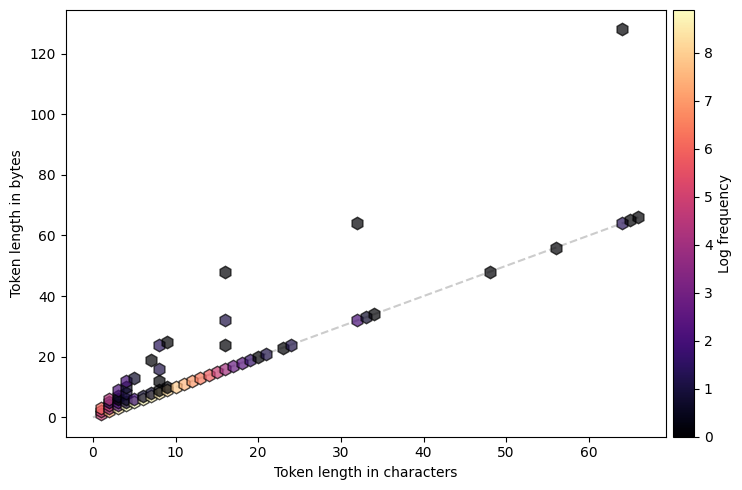

In [40]:
fig=plt.figure(figsize=(8,5))
norm=mpl.colors.Normalize(vmin=0,vmax=np.log(token_lens.max()))
x,y=np.nonzero(token_lens)
for xi,yi in zip(x,y):
  plt.plot(xi,yi,'kh',alpha=.7,markersize=9,
           markerfacecolor=plt.cm.magma(norm(np.log(token_lens[xi,yi]))))

sm = mpl.cm.ScalarMappable(cmap=mpl.cm.magma,norm=norm)
cbar = plt.colorbar(sm,ax=fig.gca(),pad=.01)
cbar.set_label('Log frequency')
plt.plot([0,xi],[0,xi],'--',color=[.8,.8,.8],zorder=-100)

# prettify the plot
plt.gca().set(xlabel='Token length in characters',
              ylabel='Token length in bytes')

plt.tight_layout()
plt.show()


## Task_2
- Find the tokens that have a mismatch between character and byte
count. You should find 873 tokens with mismatching lengths. Print
out 30 randomly selected tokens separated by a pipe symbol (the
vertical line). Figure 2.12 shows a random subset

In [48]:
noteq = np.where(token_len_char != token_len_byte)[0]
print(f'There are {len(noteq)} tokens with unequal lengths.\nHere are 30:\n')

for idx in noteq[np.random.randint(0,len(noteq),30)]:
  print(f'{tokenizer.decode([idx])} | ',end='')

There are 873 tokens with unequal lengths.
Here are 30:

�� | �� | τ | .� | р | َ | •• | е | � | � | و | � | � | � | ン | к | ¯¯¯¯ |          | � | ב | � | ———— | ��� | ヴァ | 将 | て | � | 、 |  � | ク | 

In [49]:
for idx in noteq:
  print(tokenizer.decode([idx]))

�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
�
 �
 –
 —
—
�
…
 �
�
 
–
 �
�
é
•
­
 …
��
�
 £
——
  
・
�
�
¯
¯¯
Â
 �
 •
  
の
Ã
ÃÂ
ÃÂÃÂ
 �
ー
��
 ±
��
 裏
ン
�
á
��
°
─
 �
……
®
��
█
™
————
──
 §
�
    
í
ス
��
¯¯¯¯
ö
ü
·
 Poké
ル
ラ
‐
ÃÂÃÂÃÂÃÂ
​
 −
 Pokémon
…"
██
ó
ā
��
 �
�
 €
 �
 ©
 �
ä
イ
    
….
�
��
ア
龍
�
ー�
����
″
 �
 �
ñ
リ
�
×
ا
ō
ト
 �
 �
 »
.—
「
」
ド
�
ل
��
 ×
è
−
ク
 ·
 �
 �
 �
ッ
ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ
————————
£
 �
о
 →
¯¯¯¯¯¯¯¯
"—
神
の�
★
シ
…………
�
────
а
ウ
ç
©
ロ
 �
§
ィ
。
е
�
�
α
 �
′
 �
フ
の�
»
�
 �
        
ゴ
�
�
 �
´
��
い
�
士
ón
и
 �
 μ
 �
ī
�
龍�
—"
ドラ
 │
�
�
�
�
�
マ
 ​
 裏�
ū
т
████
オ
 �
 �
魔
és
‑
�
ジ
 ―
 «
án
р
æ
��
ú
的
…]
人
с
カ
デ
 ­
 °
░
ée
ん
н
し
±
�
ي
        
�
�醒
••
�
�
â
ゴン
 (£
ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ
ャ
½
 █
 �
��
ن
ヘ
タ
、
ال
エ
��
覚醒
�
ガ
 �
 […]
�
 ★
ブ
ø
レ
�
à
«
َ
テ
 ‎
"…

# Part_2:Visualizing Token lengths

## Task_1
- Write code to produce Figure 2.13. This figure shows the token length
on the y-axis, as a function of the token index on the x-axis, for
characters and for bytes.

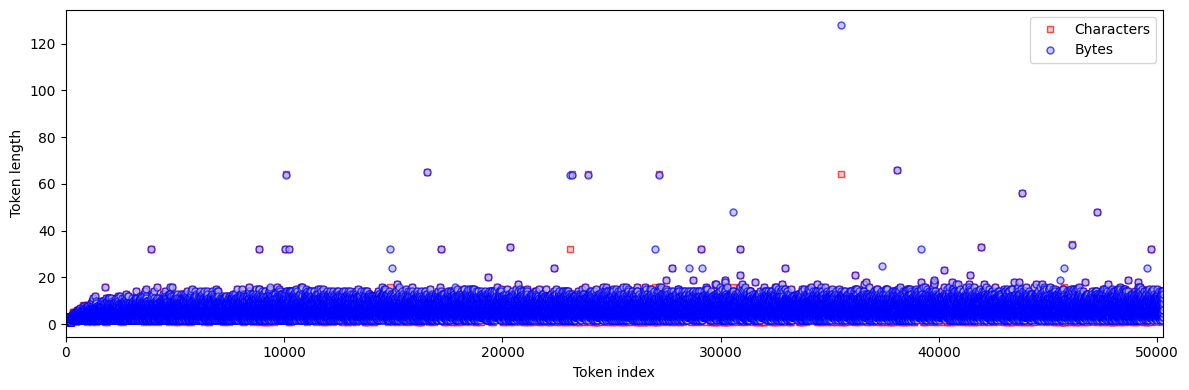

In [61]:

plt.figure(figsize=(12,4))

# use for plotting only the first N tokens
max2plot = tokenizer.vocab_size #600

# note: I added a small y-axis offset to help visualize discrepancies
plt.plot(token_len_char[:max2plot]+.1,'rs',label='Characters',markerfacecolor=[.9,.7,.7,.7],markersize=5)
plt.plot(token_len_byte[:max2plot],'bo',label='Bytes',markerfacecolor=[.7,.7,.9,.7],markersize=5)

plt.legend()
plt.gca().set(xlabel='Token index',ylabel='Token length',xlim=[-10,max2plot+10])

plt.tight_layout()
plt.show()

In [53]:
max2plot = tokenizer.vocab_size
max2plot

50257

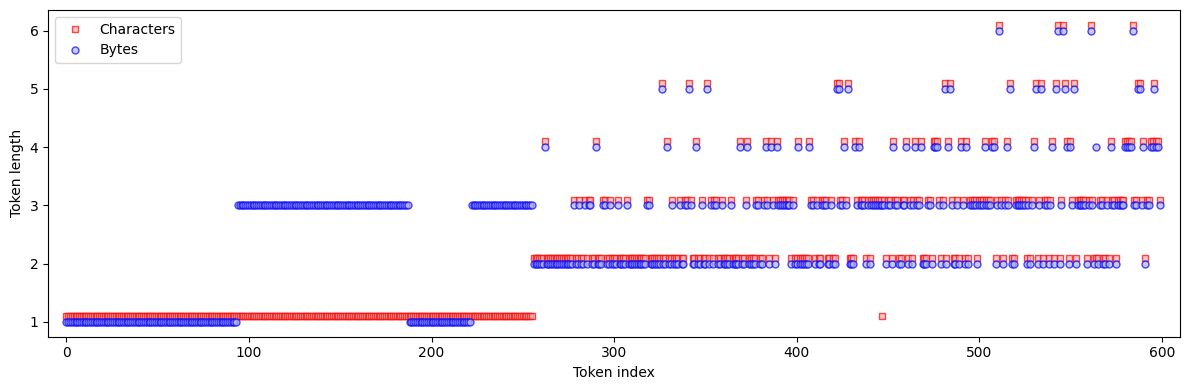

In [64]:
plt.figure(figsize=(12,4))

# use for plotting only the first N tokens
max2plot=600 #600

# note: I added a small y-axis offset to help visualize discrepancies
plt.plot(token_len_char[:max2plot]+.1,'rs',label='Characters',markerfacecolor=[.9,.7,.7,.7],markersize=5)
plt.plot(token_len_byte[:max2plot],'bo',label='Bytes',markerfacecolor=[.7,.7,.9,.7],markersize=5)

plt.legend()
plt.gca().set(xlabel='Token index',ylabel='Token length',xlim=[-10,max2plot+10])

plt.tight_layout()
plt.show()

# Part_3:Finding the mismatch length tokens

## Task_1:
- Write code to create Figure 2.14. Each token index has a small circle
plotted at y = 0 (same number of characters as bytes) or y = 1 (more
bytes than characters). Add small random jitters to help visualize
the density of dots